# Bank Marketing Classification

## Machine Learning Capstone Project

### Classification Track - Review 1

This notebook implements and evaluates machine learning classification algorithms using the Bank Marketing dataset.

The objective is to predict whether the client will subscribe to a term deposit on demographic, financial, and previous marketing campaign information.

This notebook covers: 

1. Dataset Loading and Audit
2. Exploratory Data Analysis
3. Data Cleaning
4. Preprocessing and Feature Engineering
5. Classification Model Implementation 
6. Model Evaluation and Comparison

# 1. Importing Required Libraries

In [4]:
# Data Manipulation
import pandas as pd
import numpy as np
# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Display Settings
pd.set_option('display.max_columns', None)
# Reproductibility
RANDOM_STATE = 42

# 2. Dataset Loading 

For the initial pahse of this project, we are use `bank.csv`, smaller subset of the complete Bank Marketing dataset. This allows us to develop and test the machine learning pipeline before later comparing the results with the complete dataset.

In [5]:
# Load the dataset
file_path = '../data/classification/bank.csv'
df = pd.read_csv(file_path, sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


# 3.Dataset Audit

This section examines the structure and quality of the dataset, including its dimensions, data types, missing values, and target class distribution.

In [6]:
# Dataset dimensions
print("Dataset shape:", df.shape)
# Column data types
print("\n Data types:")
display(df.dtypes)
# Missing values
print("\n Missing values:")
display(df.isnull().sum())
# Target class distribution
print("\n Target class distribution:")
display(df['y'].value_counts())
print("\n Target class distribution (percentage):")
display(df['y'].value_counts(normalize=True) * 100)

Dataset shape: (4521, 17)

 Data types:


age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object


 Missing values:


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


 Target class distribution:


y
no     4000
yes     521
Name: count, dtype: int64


 Target class distribution (percentage):


y
no     88.476001
yes    11.523999
Name: proportion, dtype: float64

### Dataset Audit Insights 

- The dataset contains 4,521 records, consisting of 16 input features and one target variable (`y`).
- The dataset contains both numerical and categorical features, meaning categorical variables will require encoding before machine learning models can be trained.
- No missing values were identified in any column; therefore, missing-value imputation is not required.
- The target variable is significantly imbalanced, with approximately 88.48% of customers belonging to the `no` class and 11.52% belonging to the `yes` class.
- Because of this class imbalance, accuracy alone may not provide a complete evaluation of model performance. Additional evaluation metrics will therefore be considered.

# 4. Exploratory Data Analysis (EDA)

This section explores the distributions and relationships within the dataset using visualizations. The analysis focuses on the target variable, individual features distributions, correlations between numerical variables, and relationships between selected between selected features and the target variable.

## 4.1 Target Variable Distribution

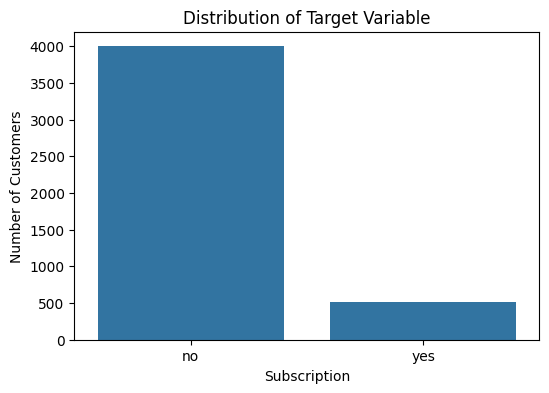

In [7]:
# Visualize the distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(data = df, x='y')
plt.title('Distribution of Target Variable')
plt.xlabel('Subscription')
plt.ylabel('Number of Customers')
plt.show()

### Observation 

The target variable is highly imbalanced. The majority of the customers did not subscribe to a term deposit, while only a relatively small proportion subscribed. This confirms the class imbalnce indentifed during audit and indicates that model performance should not be evaluated using accuracy alone.

## 4.2 Numerical Feature Distributions

In [8]:
# Identify numerical columns
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
# Remove the target variable if present
numerical_features = [col for col in numerical_features if col != 'y']
numerical_features

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

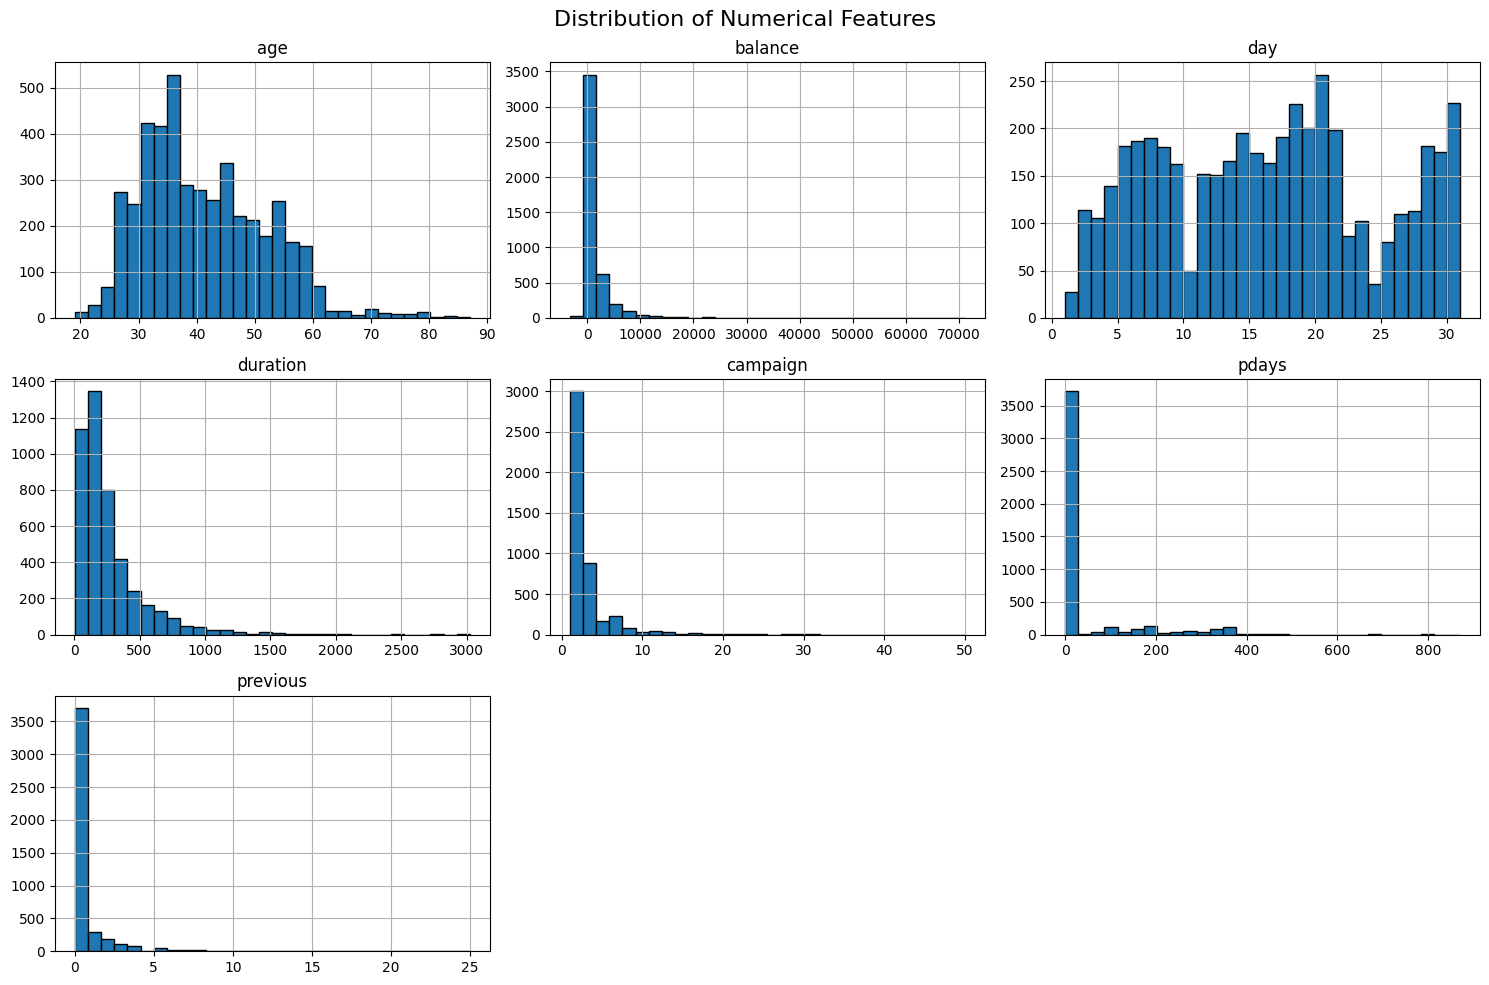

In [9]:
# Distribution plots for numerical features
df[numerical_features].hist(
figsize = (15,10),
bins = 30,
edgecolor = "black"
)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

### Observations

- **Age:** Most customers are concentrated between approximately 30 and 50 years old, with fewer observations at the extreme ends of the age range.
- **Balance:** The balance feature is highly right-skewed. Most customers have relatively low account balance, while small number have exceptionally high balances.
- **Day:** Customer contacts are distributed across the days of month, although the distribution is not uniform.
- **Duration:** Call duration is strongly right-skewed. Most calls are relatively shorter, while a small numbers of calls have long durations.
- **Campaign:** Most customers were contacted only a small number of times during the campaign, with the frequency decreasing as the number of contacts increases.
- **Pdays:** A large proportion of observations have a value of `-1`, indicating that these customers were not previously contacted before the current campaign.
- **Previous:** Most customers have not been contacted in previous campaigns, as indicated by the high concentration of values near zero.

## 4.3 Categorical Feature Distributions

In [10]:
# Identify categorical features
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()
# Remove the target variable
categorical_features = [col for col in categorical_features if col != "y"]
categorical_features

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome']

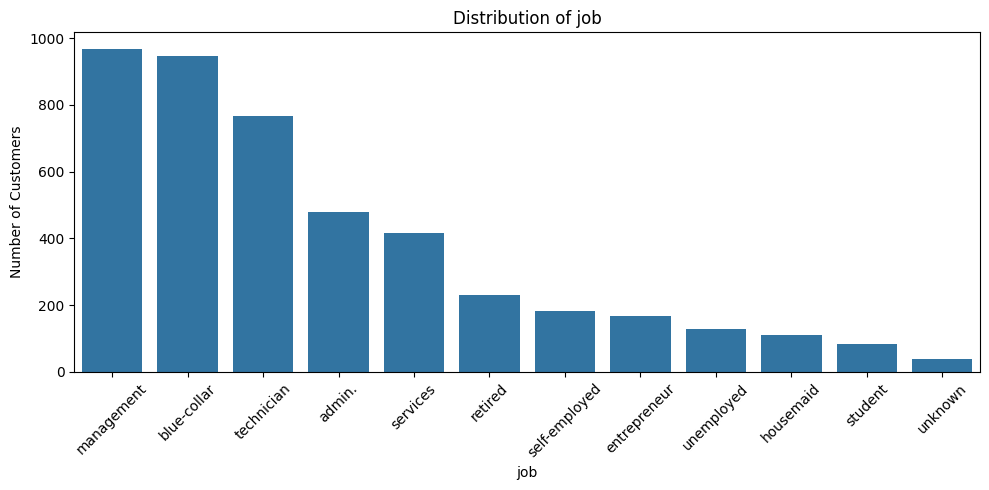

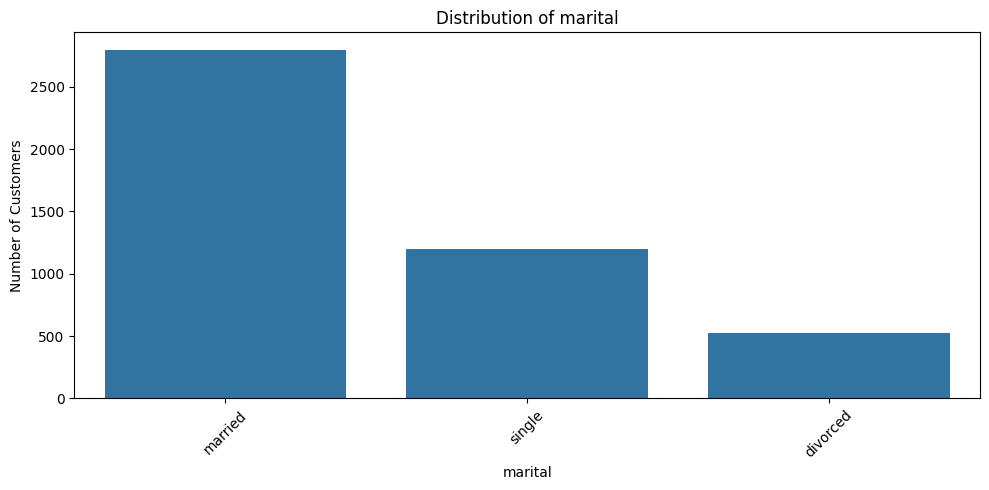

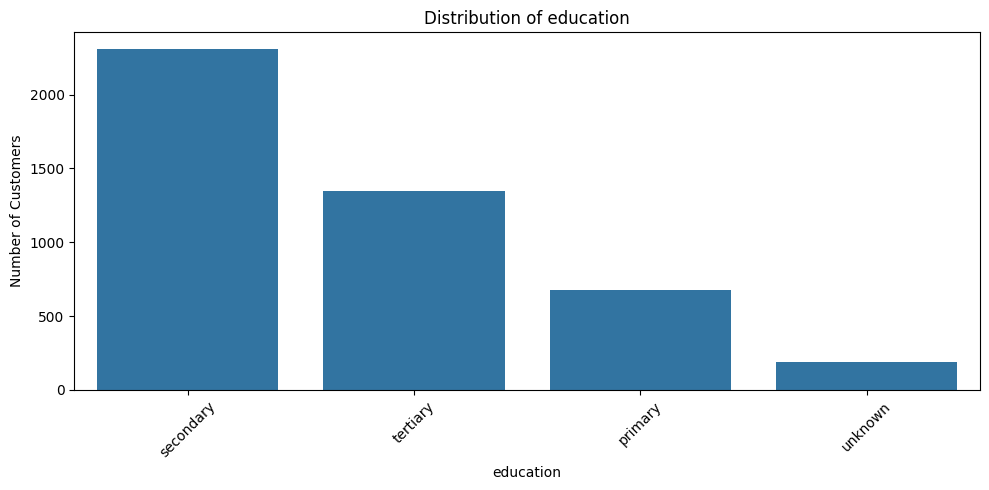

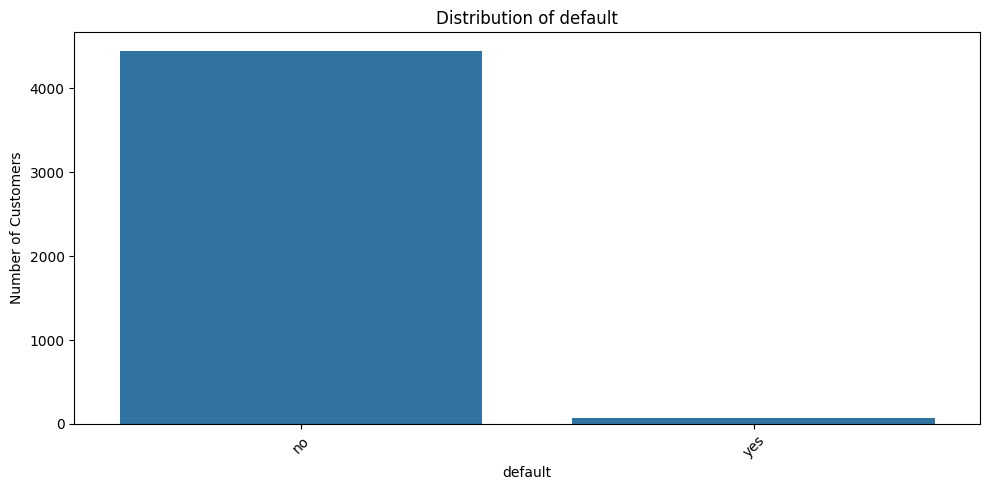

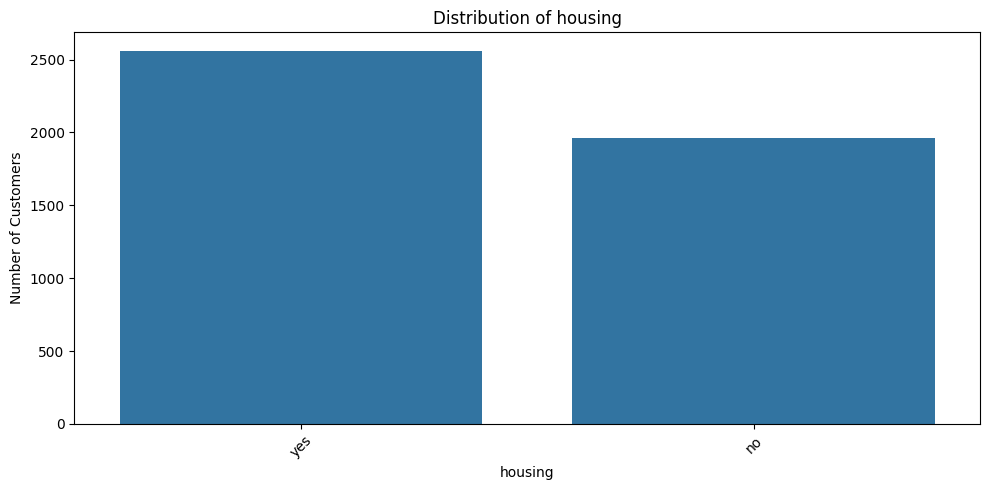

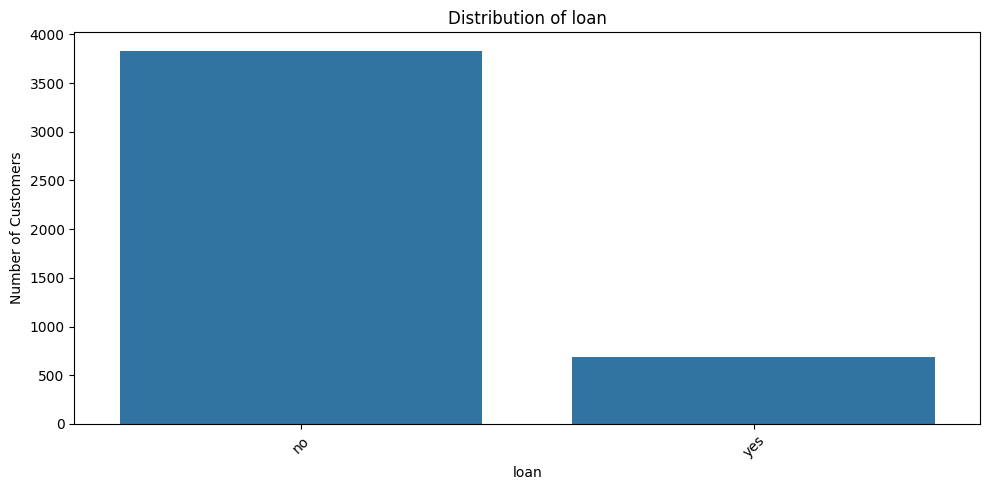

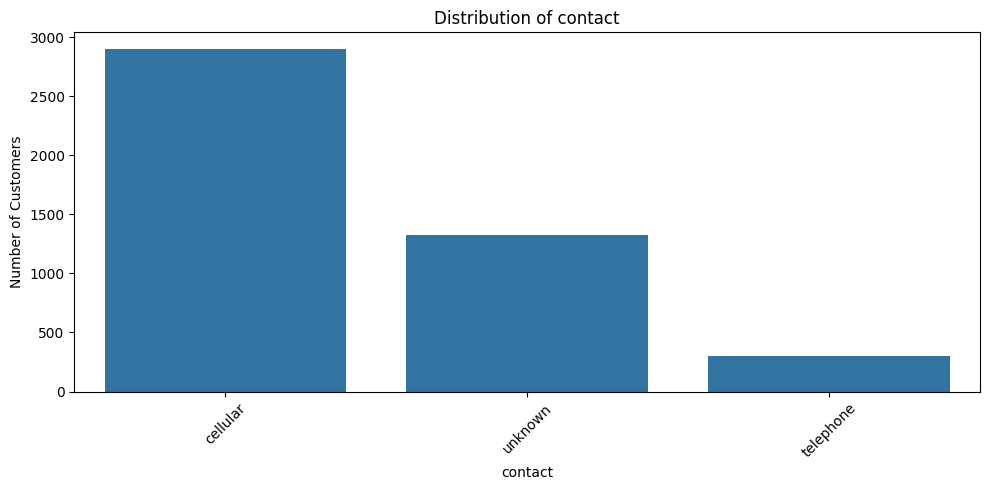

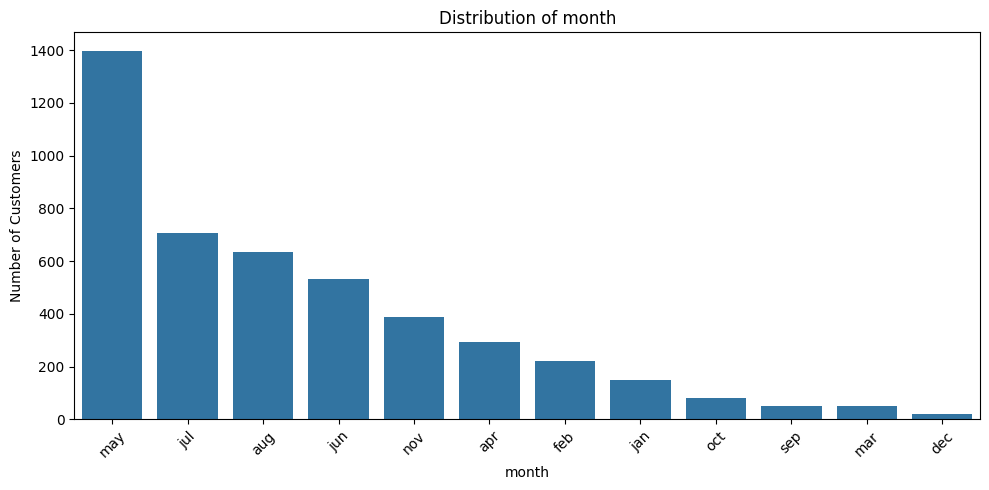

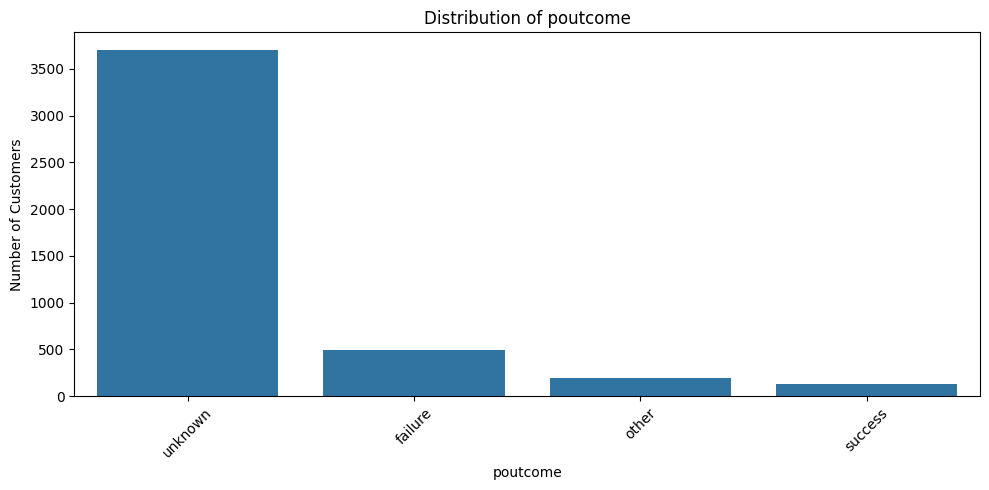

In [11]:
# Distribution plots for categorical features
for column in categorical_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index
    )
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Key Observations from Feature Distributions

- Several numerical features, including `balance`, `duration`, `campaign`, and `previous`, show right-skewed distributions and contain potential extreme values.
- The `pdays` feature contains a large concentration of `-1` values, indicating customers who were not previously contacted.
- Most customers fall within the middle-age range, with fewer observations at very young and older ages.
- The categorical variables show varying levels of imbalance. For example, the `default` feature is highly dominated by the "no" category.
- Campaign activity is concentrated in specific months, particularly May.
- The dataset contains a mixture of numerical and categorical variables, which will require appropriate preprocessing before model training.

## Correlation Analysis

A correlation heatmap is used to examine the relationships between numerical features in the dataset.

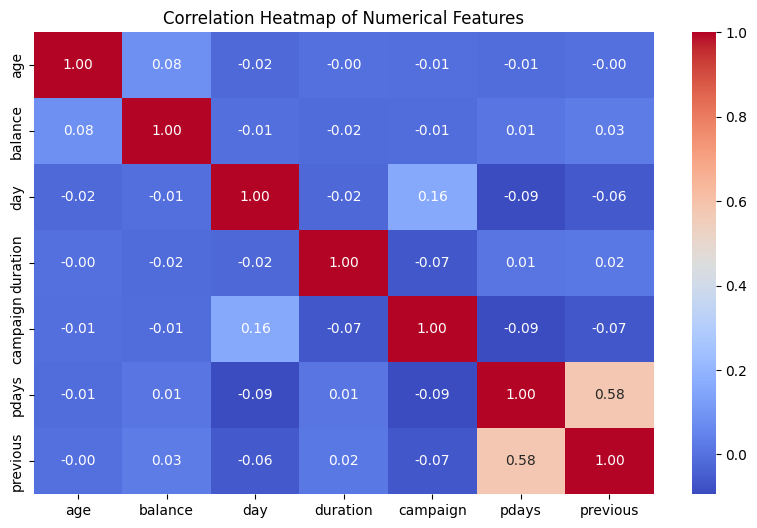

In [12]:
# Calculate the correlation matrix for numerical features
correlation_matrix = df[numerical_features].corr()
# Create the correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Insight

The correlation analysis shows that most numerical features have weak linear relationships with one another. The strongest positive correlation is between `pdays` and `previous` (0.58), indicating a moderate relationship between the number of days since a previous contact and the number of previous contacts.

Most other feature pairs have correlation values close to zero, suggesting that they do not have strong linear relationships.

## Feature-Target Relationships

In [13]:
# Convert the target variable to numerical values for visualization
df['y_numeric'] = df['y'].map({'no': 0, 'yes': 1})
df[['y', 'y_numeric']].head()

,y,y_numeric
0,no,0
1,no,0
2,no,0
3,no,0
4,no,0


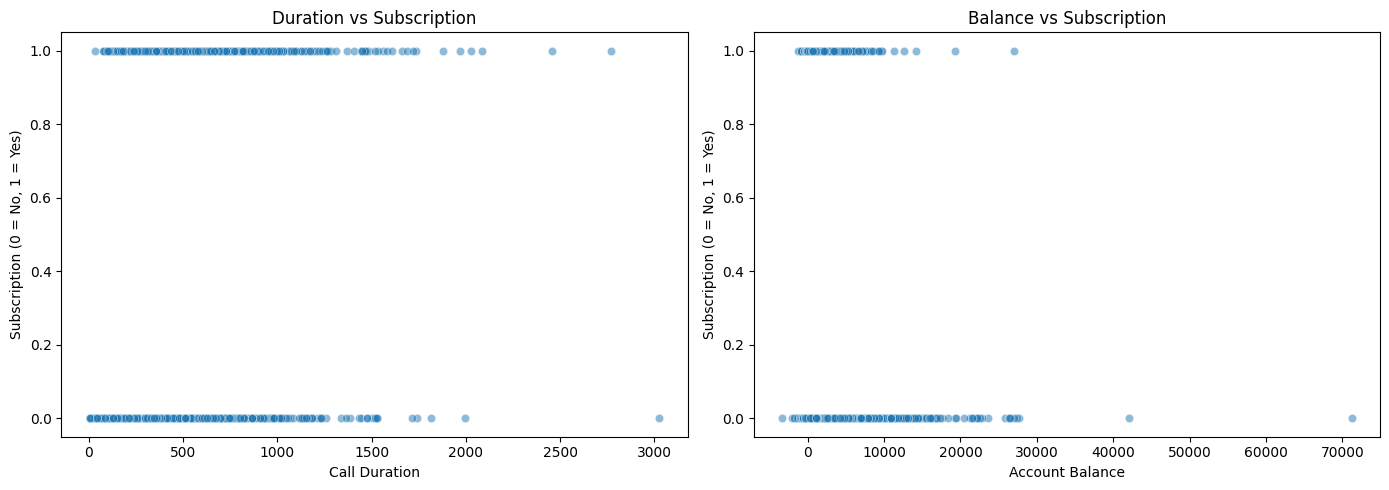

In [14]:
# Create scatter plots showing feature-target relationships
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Duration vs Target
sns.scatterplot(
    data=df,
    x='duration',
    y='y_numeric',
    alpha=0.5,
    ax=axes[0]
)
axes[0].set_title('Duration vs Subscription')
axes[0].set_xlabel('Call Duration')
axes[0].set_ylabel('Subscription (0 = No, 1 = Yes)')
# Balance vs Target
sns.scatterplot(
    data=df,
    x='balance',
    y='y_numeric',
    alpha=0.5,
    ax=axes[1]
)
axes[1].set_title('Balance vs Subscription')
axes[1].set_xlabel('Account Balance')
axes[1].set_ylabel('Subscription (0 = No, 1 = Yes)')
plt.tight_layout()
plt.show()

### Insight

The scatter plots show that call duration appears to have a stronger relationship with subscription outcome than account balance. Customers who subscribed tend to include more observations with longer call durations, suggesting that `duration` may be a useful feature for predicting the target variable.

Account balance shows considerable overlap between customers who subscribed and those who did not, indicating that balance alone may not strongly separate the two classes. Extreme account balance values are also present and should be considered during the preprocessing stage.

In [ ]:
# Remove the temporary visualization column
df.drop(columns=['y_numeric'], inplace=True)

# 3. Data Cleaning

## Checking for Duplicate Records

In [15]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


### Insight

No duplicate records were found in the dataset. Therefore, no duplicate removal was necessary.

## Outlier Detection

Boxplots are used to identify potential outliers in the numerical features of the dataset.

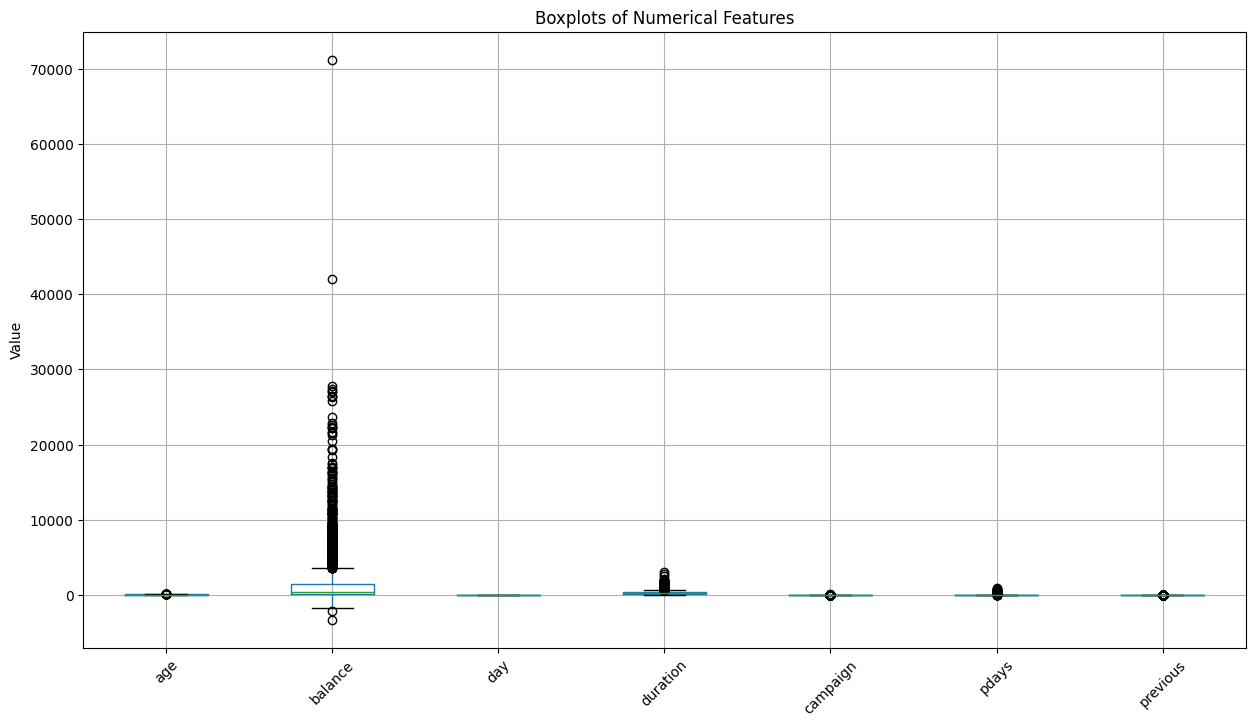

In [16]:
# Visualize potential outliers using boxplots
plt.figure(figsize=(15, 8))
df[numerical_features].boxplot()
plt.title('Boxplots of Numerical Features')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.show()

In [17]:
# Count potential outliers using the IQR method
outlier_counts = {}
for column in numerical_features:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    outlier_counts[column] = len(outliers)
# Display the number of potential outliers
outlier_counts

{'age': 38,
 'balance': 506,
 'day': 0,
 'duration': 330,
 'campaign': 318,
 'pdays': 816,
 'previous': 816}

### Outlier Analysis and Treatment

The IQR method identified potential outliers in several numerical features, particularly `balance`, `duration`, `campaign`, `pdays`, and `previous`.

These values were not automatically removed because they may represent legitimate customer characteristics and campaign outcomes rather than data-entry errors. For example, a high account balance or a long call duration can be valid observations.

Therefore, the potential outliers will be retained. Appropriate preprocessing and scaling techniques will be considered during the model preparation stage to reduce the influence of extreme values where necessary.

In [18]:
# Calculate the percentage of potential outliers
outlier_percentage = {
    column: round((count / len(df)) * 100, 2)
    for column, count in outlier_counts.items()
}
outlier_percentage

{'age': 0.84,
 'balance': 11.19,
 'day': 0.0,
 'duration': 7.3,
 'campaign': 7.03,
 'pdays': 18.05,
 'previous': 18.05}

### Final Data Cleaning Summary

The dataset contains no missing values and no duplicate records. Potential outliers were identified using the IQR method in several numerical features.

The highest proportions of potential outliers were found in `pdays` and `previous` (18.05%), followed by `balance` (11.19%). These observations were retained because they may represent legitimate customer and campaign characteristics rather than data-entry errors. Removing all of these observations could result in significant information loss.

Therefore, no rows were removed during the data cleaning stage. Appropriate encoding and scaling techniques will be applied during preprocessing.

# 4. Preprocessing and Feature Engineering

## Feature and Target Separation

The dataset is separated into input features (`X`) and the target variable (`y`) before performing the train-test split.

In [19]:
# Separate features and target variable
X = df.drop(columns=['y'])
y = df['y']
print("Feature matrix shape:", X.shape)
print("Target variable shape:", y.shape)

Feature matrix shape: (4521, 17)
Target variable shape: (4521,)


In [20]:
print(X.columns.tolist())

['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y_numeric']


In [21]:
# Remove the target and temporary visualization column
X = df.drop(columns=['y', 'y_numeric'])
# Target variable
y = df['y']
print("Feature matrix shape:", X.shape)
print("Target variable shape:", y.shape)

Feature matrix shape: (4521, 16)
Target variable shape: (4521,)


## Train-Test Split

The dataset is divided into training and testing sets using a stratified split to preserve the original class distribution in both subsets.

In [31]:
from sklearn.model_selection import train_test_split
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)
# Display the shapes of the datasets
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)
print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set shape: (3616, 17)
Testing set shape: (905, 17)

Training target distribution:
y
no     88.46792
yes    11.53208
Name: proportion, dtype: float64

Testing target distribution:
y
no     88.508287
yes    11.491713
Name: proportion, dtype: float64


### Split Verification

The stratified train-test split successfully preserved the original target class distribution in both the training and testing sets. This is particularly important because the target variable is imbalanced.

## Feature Identification

The input features are separated into numerical and categorical groups so that appropriate preprocessing techniques can be applied to each type.

In [32]:
# Identify categorical and numerical features
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()
print("Numerical features:")
print(numerical_features)
print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'previously_contacted']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


## Encoding and Scaling

Numerical features are standardized using `StandardScaler`, while categorical features are transformed using one-hot encoding. The preprocessing transformations are fitted only on the training data to prevent data leakage.

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# Define preprocessing for numerical features: standard scaling
numerical_transformer = StandardScaler()
# Define preprocessing for categorical features: one-hot encoding
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)
# Combine preprocessing steps using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_transformer, numerical_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

In [34]:
# Fit the preprocessor on the training data only
X_train_preprocessed = preprocessor.fit_transform(X_train)
# Transform the test data using the fitted preprocessor
X_test_preprocessed = preprocessor.transform(X_test)
print("Processed training set shape:", X_train_preprocessed.shape)
print("Processed test set shape:", X_test_preprocessed.shape)

Processed training set shape: (3616, 52)
Processed test set shape: (905, 52)


### Preprocessing Results

The preprocessing pipeline was successfully applied to the dataset. The original 16 input features were transformed into 51 features after numerical scaling and one-hot encoding of categorical variables.

The preprocessing transformations were fitted exclusively on the training data and then applied to the testing data, preventing data leakage.

## Feature Engineering

A new feature named `previously_contacted` is created using the `pdays` variable. In this dataset, a value of `-1` in `pdays` indicates that the customer was not contacted during a previous marketing campaign.

The engineered feature explicitly distinguishes customers who had previous campaign contact from those who did not. This may improve model performance by providing a clearer representation of previous customer interaction history.

In [27]:
# Create a binary feature indicating whether the customer was contacted during the previous campaign
df['previously_contacted'] = (df["pdays"] != -1).astype(int)
# Display the distribution of the new feature
df['previously_contacted'].value_counts()

previously_contacted
0    3705
1     816
Name: count, dtype: int64

In [28]:
print("Previously contacted feature distribution:")
print(df['previously_contacted'].value_counts())
print("\nPreviously contacted feature distribution (percentage):")
print(df['previously_contacted'].value_counts(normalize=True) * 100)

Previously contacted feature distribution:
previously_contacted
0    3705
1     816
Name: count, dtype: int64

Previously contacted feature distribution (percentage):
previously_contacted
0    81.950896
1    18.049104
Name: proportion, dtype: float64


In [29]:
df[["pdays", "previously_contacted"]].head(10)

,pdays,previously_contacted
0,-1,0
1,339,1
2,330,1
3,-1,0
4,-1,0
5,176,1
6,330,1
7,-1,0
8,-1,0
9,147,1


In [30]:
# Separate features and target variable
X = df.drop(columns=['y', 'y_numeric'], errors='ignore')
y = df['y']
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (4521, 17)
Target vector shape: (4521,)
